## IMPLEMENTING A SIMPLIFIED ATTENTION MECHANISM

ATTENTION MECHANISM
Consider the following input sentence, which has already been embedded into 3- dimensional vectors.

We choose a small embedding dimension for illustration purposes to ensure it fits on the page without line breaks

In [ ]:
import torch
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

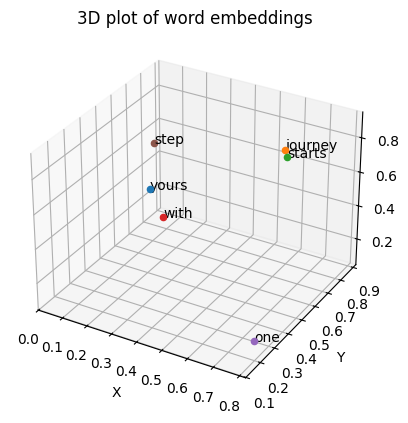

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

words = ["yours","journey","starts","with","one","step"]
x_coords = inputs[:,0].numpy()
y_coords = inputs[:,1].numpy()
z_coords = inputs[:,2].numpy()
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
for x,y,z,word in zip(x_coords,y_coords,z_coords,words):
  ax.scatter(x,y,z)
  ax.text(x,y,z,word,fontsize=10)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.title("3D plot of word embeddings")
plt.show()

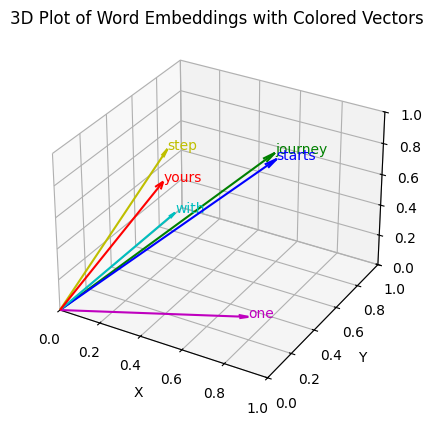

In [ ]:
# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y']

# Plot each vector with a different color and annotate with the corresponding word
for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()

Each row represent a word, and each column represent an embedding dimension

The second input token serves as the query


In [ ]:
query = inputs[1] #2nd input token is the query
attention_scores_2 = torch.empty(inputs.shape[0])
for i,x_i in enumerate(inputs):
  attention_scores_2[i] = torch.dot(x_i,query)
print(attention_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In the next step, we normalize each of the attention scores that we computed previously

The main goal behind the normalization is to obtain attention weights that sum up to 1

This normalization is a convention that is useful for interpreation and for maintaining training stability in an LLM

Here a straighforward method for acheiving this normalization step

In [ ]:
attn_weights_2_tmp = attention_scores_2 / attention_scores_2.sum()
print("Attention_weights:",attn_weights_2_tmp)
print("sum",attn_weights_2_tmp.sum())

Attention_weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
sum tensor(1.0000)


In practise, it is more common and advisable to use the softmax function for nomralization.

**This approach is better at managing extreme values and offers more favorable gradient properties during training **

Below is a basic implementation of the softmax function for normalizing the attention scores:

In [ ]:
def softmax_naives(x):
  return torch.exp(x)/ torch.exp(x).sum(dim=0)
att_weight_2_naive = softmax_naives(attention_scores_2)
print("Attention weights",att_weight_2_naive)
print("Sum",att_weight_2_naive.sum())


Attention weights tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum tensor(1.)


As the output shows, the softmax function also meets the objectives and normalizes the attention weights such that they sum up to 1:

**In addition, the softmax function ensures that the attention weights are always positive. This makes the output interpretable as probabilities or relative importantce, where higher weights indicate greater importance**

Note that this naive softmax implmementation ( softmax_naive) may encounter numerical instability problems, such as overflow and underflow, when dealing with large or small input values ,

Therefore, in practise, its advisable to use the Pytorch implementation of softmax, which has been extensively optimizes for performance

In [ ]:
attn_weights_2 = torch.softmax(attention_scores_2, dim=0)
print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


In this case, we see that it yeilds the same results as our previious softmax naive function:

Then context vector z(2) is calculated as weighted sum of all input vectors.

This involves multiplying each input vector by its corresponding attention weight


In [ ]:
print("inputs",inputs)

query = inputs[1] # 2nd input token is the query
print("query",query)
# Re-calculate attention scores based on the current inputs
attention_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attention_scores_2[i] = torch.dot(x_i, query)

# Re-calculate attention weights using softmax
attn_weights_2 = torch.softmax(attention_scores_2, dim=0)
print("attention_weights",attn_weights_2)
context_vec_2 = torch.zeros(query.shape)
print(context_vec_2)
for i,x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i]*x_i

print(context_vec_2)

inputs tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])
query tensor([0.5500, 0.8700, 0.6600])
attention_weights tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
tensor([0., 0., 0.])
tensor([0.4419, 0.6515, 0.5683])


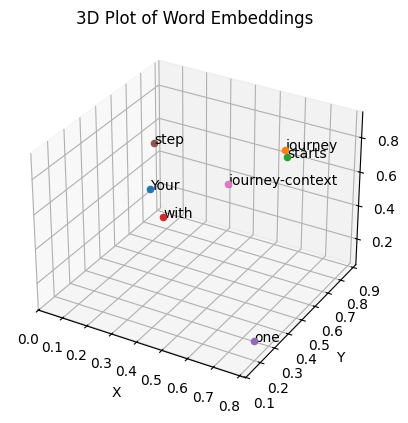

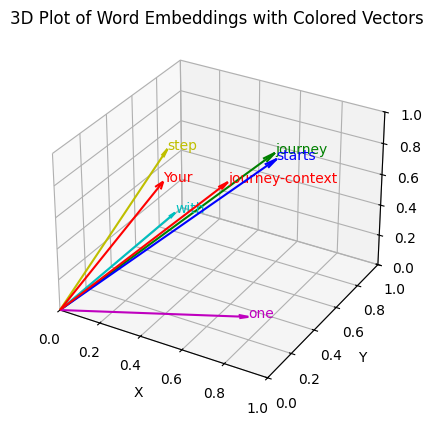

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55], # step     (x^6)
   [0.4419, 0.6515, 0.5683]]
)

# Corresponding words
words = ['Your', 'journey', 'starts', 'with', 'one', 'step', 'journey-context']

# Extract x, y, z coordinates
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot each point and annotate with corresponding word
for x, y, z, word in zip(x_coords, y_coords, z_coords, words):
    ax.scatter(x, y, z)
    ax.text(x, y, z, word, fontsize=10)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Plot of Word Embeddings')
plt.show()

# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'r']

# Plot each vector with a different color and annotate with the corresponding word
for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()

Now, we can extend this computation to calculate attention weights and context vectors for all inputs

First we add an additional for loop to compute dot product for all pairs for inputs


In [ ]:
attn_scores = torch.empty(inputs.shape[0], inputs.shape[0])

for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores[i, j] = torch.dot(x_i, x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310, 0.7935],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865, 1.1849],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605, 1.1694],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565, 0.6626],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935, 0.5600],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450, 0.8559],
        [0.7935, 1.1849, 1.1694, 0.6626, 0.5600, 0.8559, 0.9427]])


Each element in the preceding tensor represents an attention score between each pair of inputs.

When computing the preceding attention score tensor, we used for-loops in Python.

However, for-loops are generally slow, and we can achieve the same results using matrix multiplication:

In [ ]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310, 0.7935],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865, 1.1849],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605, 1.1694],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565, 0.6626],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935, 0.5600],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450, 0.8559],
        [0.7935, 1.1849, 1.1694, 0.6626, 0.5600, 0.8559, 0.9427]])


We now normalize each row so that the values in each row sum to 1:

In [ ]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.1792, 0.1713, 0.1692, 0.1061, 0.1042, 0.1240, 0.1459],
        [0.1180, 0.2026, 0.1986, 0.1056, 0.0921, 0.1346, 0.1486],
        [0.1184, 0.2017, 0.1981, 0.1058, 0.0943, 0.1332, 0.1485],
        [0.1223, 0.1768, 0.1744, 0.1246, 0.1077, 0.1467, 0.1476],
        [0.1305, 0.1675, 0.1689, 0.1169, 0.1607, 0.1108, 0.1446],
        [0.1180, 0.1861, 0.1813, 0.1211, 0.0842, 0.1615, 0.1478],
        [0.1277, 0.1889, 0.1860, 0.1121, 0.1011, 0.1359, 0.1483]])


In the context of using PyTorch, the dim parameter in functions like torch.softmax specifies the dimension of the input tensor along which the function will be computed.
By setting dim=-1, we are instructing the softmax function to apply the normalization along the last dimension of the attn_scores tensor  

if attn_scores is a 2D tensor (for example, with a shape of [rows,colums]),dim=-1 will normalize across the columns so that the values in each row(summing over the column dimension) sum up to 1

lets breifly verify that the rows indeed all sum to 1:

In [ ]:
row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
print("Row 2 sum:", row_2_sum)
print("All row sums:", attn_weights.sum(dim=-1))

Row 2 sum: 1.0
All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In the third and last step, we now use these attention weights to compute all context vectors via matrix multiplication:

In [ ]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4420, 0.6016, 0.5774],
        [0.4419, 0.6515, 0.5683],
        [0.4429, 0.6499, 0.5673],
        [0.4321, 0.6330, 0.5536],
        [0.4635, 0.5997, 0.5326],
        [0.4213, 0.6505, 0.5651],
        [0.4397, 0.6372, 0.5635]])


We can double-check that the code is correct by comparing the 2nd row with the context vector z(2) calculated previously

In [ ]:
print("Previous 2nd context vector:", context_vec_2)

Previous 2nd context vector: tensor([0.4419, 0.6515, 0.5683])


#IMPLEMENTING SELF ATTENTION WITH TRAINABLE WEIGHTS

In [ ]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)
inputs.shape

torch.Size([6, 3])

Let's begin by defining a few variables:

#A The second input element
#B The input embedding size, d = 3
#C The output embedding size d_out = 2

In [ ]:
x_2 = inputs[1] #A
d_in = inputs.shape[1] #B
d_out = 2 #C

Note that in GPT-like models, the input and output dimensions are usually the same.

But for illustration purposes, to better follow the computation, we choose different input (d_in=3) and output (d_out=2) dimensions here.

Next, we initialize the three weight matrices, Wq, Wk, and Wv


In [ ]:
a = torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)
W_key = torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)


In [ ]:
print(W_query)

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])


In [ ]:
print(W_key)

Parameter containing:
tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]])


In [ ]:
print(W_value)

Parameter containing:
tensor([[0.0756, 0.1966],
        [0.3164, 0.4017],
        [0.1186, 0.8274]])


Note that we are setting requires_grad = False to **reduce clutter** in the outputs for illustration purposes

If we were to use the weight matrices for model training, we would set requires_grad=True to update these matrices during model training.

Next, we compute the query, key, value vectors as shown earlier



In [ ]:
x_2


tensor([0.5500, 0.8700, 0.6600])

In [ ]:
query2 = x_2 @ W_query
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value


In [ ]:
#3*1 * 3*2
print(query2)

tensor([0.4306, 1.4551])


As we can see based on the output for the query, this results in a 2-dimensional vector

This is becuase : we set number of columns of the corresponding weight matrix via, d_out to 2

Even though out temporary goal is only to compute the one context vector z2 we still require key and value for all input element
This is becuase they are involved in computing the attention weights with respect to the query q(2)

We can obtain all keys and matrices multiplication

In [ ]:
keys = inputs @ W_key
values = inputs @ W_value
queries = inputs @ W_query
print("keys.shape:", keys.shape)

print("values.shape:", values.shape)

print("queries.shape:", queries.shape)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])
queries.shape: torch.Size([6, 2])


As we can tell from outputs, we successfully projected the 6 input tokens from a 3D onto a 2D embedding space.

First let's compute the attention score  ω22


In [ ]:
keys_2 = keys[1]
attn_scores22 = query2.dot(keys_2)
print(attn_scores22)

tensor(1.8524)


Again, we can generalize this computation to all attention scores via matrix multiplication:

In [ ]:
attn_scores2 = query2 @ keys.T # All attention scores for given query
print(attn_scores2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [ ]:
attn_scores = queries @ keys.T # omega
print(attn_scores)

tensor([[0.9231, 1.3545, 1.3241, 0.7910, 0.4032, 1.1330],
        [1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
        [1.2544, 1.8284, 1.7877, 1.0654, 0.5508, 1.5238],
        [0.6973, 1.0167, 0.9941, 0.5925, 0.3061, 0.8475],
        [0.6114, 0.8819, 0.8626, 0.5121, 0.2707, 0.7307],
        [0.8995, 1.3165, 1.2871, 0.7682, 0.3937, 1.0996]])


We compute the attention weights by scaling the attention scores and using the softmax function we used earlier.

The difference to earlier is that we now scale the attention scores by dividing them by the square root of the embedding dimension of the keys.

Note that taking the square root is mathematically the same as exponentiating by 0.5:

In [ ]:
d_k = keys.shape[-1]
print(d_k)

2


In [ ]:
attn_weights2 = torch.softmax(attn_scores2/d_k**0.5,dim=-1)
print(attn_weights2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


WHY DIVIDE BY SQRT (DIMENSION)

Reason1 : For stablility in learning

The Softmax function is sensitive to the magnitudes of its inputs. When the inputs are large, the difference between the exponential values of each input become much more pronounced. This causes the softmax output to become "peaky" where the highest value receives almost all the probability mass and the rest receive very little.

In attention mechanisms, particularly in transformats if the dot products between query and key vectors becomes too large (like multiplying by 8 in this example), the attention scores can become very large. This results in a very sharp softmax distribution, making the model overly confident in one particular "key". Such sharp distribution can make learning unstable

In [ ]:
import torch

tensor = torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])
softmax_result = torch.softmax(tensor,dim=-1)
print("Softmax without scaling:", softmax_result)

# Multiply the tensor by 8 and then apply softmax
scaled_tensor = tensor * 8
softmax_scaled_result = torch.softmax(scaled_tensor, dim=-1)
print("Softmax after scaling (tensor * 8):", softmax_scaled_result)

Softmax without scaling: tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])
Softmax after scaling (tensor * 8): tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])


#BUT WHY SQRT?

Reason 2: To make the variance of the dot product stable

The dot product of Q and K increases the variance because multiplying two random numbers increases the variance.

The increase in variance grows with the dimension.

Dividing by sqrt (dimension) keeps the variance close to 1

In [ ]:
import numpy as np

# Function to compute variance before and after scaling
def compute_variance(dim, num_trials=1000):
    dot_products = []
    scaled_dot_products = []

    # Generate multiple random vectors and compute dot products
    for _ in range(num_trials):
        q = np.random.randn(dim)
        k = np.random.randn(dim)

        # Compute dot product
        dot_product = np.dot(q, k)
        dot_products.append(dot_product)

        # Scale the dot product by sqrt(dim)
        scaled_dot_product = dot_product / np.sqrt(dim)
        scaled_dot_products.append(scaled_dot_product)

    # Calculate variance of the dot products
    variance_before_scaling = np.var(dot_products)
    variance_after_scaling = np.var(scaled_dot_products)

    return variance_before_scaling, variance_after_scaling

# For dimension 5
variance_before_5, variance_after_5 = compute_variance(5)
print(f"Variance before scaling (dim=5): {variance_before_5}")
print(f"Variance after scaling (dim=5): {variance_after_5}")

# For dimension 20
variance_before_100, variance_after_100 = compute_variance(100)
print(f"Variance before scaling (dim=100): {variance_before_100}")
print(f"Variance after scaling (dim=100): {variance_after_100}")


Variance before scaling (dim=5): 5.42177017820783
Variance after scaling (dim=5): 1.084354035641566
Variance before scaling (dim=100): 99.48496038491935
Variance after scaling (dim=100): 0.9948496038491935


We now compute the context vector as a weighted sum over the value vectors ,

Here, the attention weights serve as a weighting factor that weighs the respective importance of each value vector

we can use matrix multiplication to obtain the output in one step:

In [ ]:
context_vec_2 = attn_weights2 @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


so far, we only compute a single context vector Z2 . In the next section, we will generalize the code to compute all context vectors in the input sequence, Z(1) to Z(T)

#Implementing a Compact Self Attention Python Class

In the previous sections, we have gone through a lot of steps to compute the self attention outputs.

This was mainly done for illustration purposes so we could go through one step at a time

In practise, with the LLM implementation in the next chapter in mind, it is helpful to orgnaize this code into a Python class as follows.

In [ ]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):
  def __init__(self,d_in,d_out):
    super().__init__()
    self.W_query = nn.Parameter(torch.rand(d_in,d_out))
    self.W_key = nn.Parameter(torch.rand(d_in,d_out))
    self.W_value = nn.Parameter(torch.rand(d_in,d_out))
  def forward(self,x):
    queries = x @ self.W_query
    keys = x @ self.W_key
    values = x @ self.W_value
    attn_scores = queries @ keys.T
    attn_weights = torch.softmax(attn_scores/keys.shape[-1]**0.5,dim=-1)
    context_vec = attn_weights @ values
    return context_vec


In this PyTorch code, SelfAttention_v1 is a class derived from nn.Module, which is a fundamental building block of PyTorch models, which provides necessary functionalities for model layer creation and management.

The init method initializes trainable weight matrices (W_query, W_key, and W_value) for queries, keys, and values, each transforming the input dimension d_in to an output dimension d_out.

During the forward pass, using the forward method, we compute the attention scores (attn_scores) by multiplying queries and keys, normalizing these scores using softmax.

Finally, we create a context vector by weighting the values with these normalized attention scores.

In [ ]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in,d_out)
print(sa_v1(inputs))


tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


Since the inputs contains six embedding vectors, we get matrix storing the six context vectors, as shown in the above result.

As a quick check, notice how the second row ( [0.3061, 0.8210]) matches the contents of context_vec_2 in the previous section.

We can improve the SelfAttention_v1 implementation further by utilizing Pytorch nn.Linear layers, which effictively perform matrix multiplication when the bias units are disabled.

Additionally a significant advantage of using nn.Linear instead of manually implementing nn.Paramter(torch.rand(..)) is that nn.Linear has an optimized weight initialization scheme, contributing to more stable and effective model trainig

In [ ]:
import torch.nn as nn
class SelfAttention_v2(nn.Module):
  def __init__(self,d_in,d_out,qkv_bias=False):
    super().__init__()
    self.W_query = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_key = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_value = nn.Linear(d_in,d_out,bias=qkv_bias)
  def forward(self,x):
    query = self.W_query(x)
    key = self.W_key(x)
    value = self.W_value(x)
    attn_scores = query @ key.T
    attn_weight = torch.softmax(attn_scores/key.shape[-1]**0.5,dim=-1)
    context_vec = attn_weight @ values
    return context_vec



| Line of Code                                    | Operation                     | Shape Explanation        | Resulting Shape |
| ----------------------------------------------- | ----------------------------- | ------------------------ | --------------- |
| `x = inputs`                                    | Input sequence                | 6 tokens, 3 features     | **(6, 3)**      |
| `query = W_query(x)`                            | Linear projection (3 → 2)     | (6,3) × (3,2)            | **(6, 2)**      |
| `key = W_key(x)`                                | Linear projection (3 → 2)     | (6,3) × (3,2)            | **(6, 2)**      |
| `value = W_value(x)`                            | Linear projection (3 → 2)     | (6,3) × (3,2)            | **(6, 2)**      |
| `attn_scores = query @ key.T`                   | Dot product between all pairs | (6,2) @ (2,6)            | **(6, 6)**      |
| `attn_weights = softmax(attn_scores / sqrt(2))` | Softmax across tokens         | (6,6) → normalized rows  | **(6, 6)**      |
| `context_vec = attn_weights @ value`            | Weighted sum of value vectors | (6,6) @ (6,2)            | **(6, 2)**      |
| `return context_vec`                            | Final attention output        | 6 tokens, each now 2-dim | **(6, 2)**      |


In [ ]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[0.2762, 0.7584],
        [0.2761, 0.7638],
        [0.2762, 0.7637],
        [0.2780, 0.7609],
        [0.2785, 0.7603],
        [0.2772, 0.7618]], grad_fn=<MmBackward0>)


You can use the SelfAttention_v2 similar to SelfAttention_v1:

Note that SelfAttention_v1 and SelfAttention_v2 give different outputs because they use different initial weights for the weight matrices since nn.Linear uses a more sophisticated weight initialization scheme

# HIDING FUTURE WORDS WITH CAUSAL ATTENTION

Let's work with the attention scores and weights from the previous section to code the casual attention mechanism

In the first step illustrated in Figure 3.20, we compute the attention weights using the softmax function as we have done in previous sections

Reuse the query and key weight matrices of the selfattention_v2 object from previous section for convenience

In [ ]:
queries = sa_v2.W_query(inputs) #A
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=1)
print(attn_weights)


tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


We can now use PyTorch's tril function to create a mask where the values above the diagonal are zero:

In [ ]:
context_length = attn_scores.shape[0]
print(context_length)

6


In [ ]:
maksed_sample = torch.tril(torch.ones(context_length,context_length))

In [ ]:
maksed_sample

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])

# we maked the upper traingle  

Upper triangle and Lower triangle matrix

In [ ]:
mask_simple = torch.tril(torch.ones(context_length,context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


Now, we can multiply this mask with the attention weights to zero out the values above the diagonal:

In [ ]:
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


As we can see, the elements above the diagonal are successfully zeroed out

The third step is to renormalize the attention weights to sum up to 1 again in each row

We can acheive this by diving each element in each row by the sum in each row:

In [ ]:
row_sums = masked_simple.sum(dim=1,keepdim=True)
masked_simple_norm = masked_simple/row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


The result is an attention weight matrix where the attention weights above the diagonal are zeroed out and where the rows sum to 1.

While we could be technically done with implementing casual attention at this point, we can take advantage of a mathematical property of the softmax function

We can implement the computation of the masked attention weights more efficiently in fewer steps.

The softmax function converts its inputs into a probablity distribution

When negative infinity values (-∞) are present in a row, the softmax function treats them as zero probability.  

(Mathematically, this is because e -∞ approaches 0.)

We can implement this more efficient masking "trick" by creating a mask with 1's above the diagonal and then replacing these 1's with negative infinity (-inf) values:



In [ ]:
mask = torch.triu(torch.ones(context_length,context_length),diagonal=1)
print(mask)

tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])


In [ ]:
attn_scores

tensor([[ 0.2899,  0.0716,  0.0760, -0.0138,  0.1344, -0.0511],
        [ 0.4656,  0.1723,  0.1751,  0.0259,  0.1771,  0.0085],
        [ 0.4594,  0.1703,  0.1731,  0.0259,  0.1745,  0.0090],
        [ 0.2642,  0.1024,  0.1036,  0.0186,  0.0973,  0.0122],
        [ 0.2183,  0.0874,  0.0882,  0.0177,  0.0786,  0.0144],
        [ 0.3408,  0.1270,  0.1290,  0.0198,  0.1290,  0.0078]],
       grad_fn=<MmBackward0>)

In [ ]:
masked = attn_scores.masked_fill(mask.bool(),-torch.inf)
print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


Now all we need to do is apply the softmanx function to these masked results, and we are done.

In [ ]:
attn_weights = torch.softmax(masked/keys.shape[-1]**0.5,dim=-1)
print(attn_weights)


tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


As we can see based on the output, the values in each row sum to 1, and no further normalization is necessary.

**Masking in Transformers sets scores for future token to a large negative value, making their influence in the softmax calculation effectively zero **

The softmax function then recalculates attention weights only among the unmasked tokens.

This process ensure no information leakage from masked tokens, focusing the model solely on the intended data.

We could now use the modified attention weights to compute the context vectors via context_vec = attention_weights @ values.

However in the next section we first cover another minor tweak to the casual attention mechanism that is useful for reducing overfitting when training LLMs




#Masking Additional Attention Weights With Dropout

In the following code example, we use a dropout rate of 50% which means masking out half of the attention weights.

When we train the GPT model in later chapter, we will use a lower dropout rate such as 0.1 to 0.2  

In the following code, we apply Pytorch dropout implementation first 6*6 tensor consisting of ones and illustration purposes



In [ ]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)  #A
example = torch.ones(6,6) #B
print(example)
print(dropout(example))

tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])
tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


When applying dropout to an Attention weight matrix with a rate of 50% half of the elements in the matrix are randomly set to zero

To compensate for the reduction in active elements, the values of the remaining elements in the matrix are scaled up by factor of 1/0.5 = 2

This scaling is cruicial to maintain the overall balance of the attention weigths, ensuring that the average influence of the attention mechanism remains consistent during both the training and inference phases.



In [ ]:
# Lets apply dropout to the attention weight matrix itself

torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)


As we can see above, the resulting attention weight matrix now has additional elements zeroed out and the remaining ones rescaled.

Having gained an understanding of casual attention and dropout masking, we will develop a concise Python class in the following section.

This class is designed to facilate the efficient application these two techniques

#IMPLEMENTING A COMPACT CAUSAL ATTENTION CLASS
In this section, we will now incorporate the causal attention and dropout modifications into the SelfAttention Python class we developed in section 3.4.

This class will then serve as a template for developing multi-head attention in the upcoming section.

Before we begin, one more thing is to ensure that the code can handle batches consisting of more than one input.

This will ensure that the CausalAttention class supports the batch outputs produced by the data loader we implemented earlier.

For simplicity, to simulate such batch inputs, we duplicate the input text examples:

2 inputs with 6 tokens each and each token has embedding dimension 3

In [ ]:
batch = torch.stack((inputs,inputs),dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


In [ ]:
class CasualAttention:
  def __init__(self,d_in,d_out,context_length,qkv_bias=False):

    super().__init__()
    self.d_out = d_out
    self.W_query = nn.Linear(d_in,d_out,qkv_bias=qkv_bias)
    self.W_key= nn.Linear(d_in,d_out,qkv_bias=qkv_bias)
    self.W_value = nn.Linear(d_in,d_out,qkv_bias=qkv_bias)
    self.register_buffer('mask',torch.triu(torch.ones(context_length,context_length),diagonal=1))
    self.droput = nn.Drouput(dropout)

  def forward(self,x):
    b,num_token,d_in = x.shape
    queries = self.W_query(x)
    keys = self.W_key(x)
    attn_scores = queries @ keys.transpose(1,2)
    # `:num_tokens` to account for cases where the number of tokens in the batch is smaller than the supported context_size
    attn_scores.masked_fill_(self.mask.bool()[:num_token,:num_token],-torch.inf)
    attn_weights = torch.softmax(attn_scores/keys.shape[-1]**0.5,dim=-1)
    attn_weights = self.dropout(attn_weights)
    context_vec = attn_weights @ values
    return context_vec






This results in 3D tensor consisting of 2 input text with 6 tokens each token is a 3-dimensional embedding vector.

The following casualattention class is similar to the SelfAttention class we implemented earlier, except that we now added the dropout and casual mask componenets as highlighted in the following code.

Step1. Compared to the previous SelfAttention_v1 class we added a dropout layer

Step2. The register_buffer call is also a new additon (more information is provided in the following text)

Step3. We transpose dimension 1 and 2, keeping the batch dimension at the first position(0)

Step4: In pytorch, operations with a trailing underscore are performed in-place, avoiding unnecessary memport copies

In [ ]:
print(d_in)

3


In [ ]:
print(d_out)

2


In [ ]:
batch.shape

torch.Size([2, 6, 3])

In [ ]:
context_length

6

In [ ]:
import torch.nn as nn

class CasualAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        # Fix: diagonal argument belongs to triu, not register_buffer
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        # Fix: Consistent variable names and definitions
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2)
        # Fix: slicing the mask correctly
         # `:num_tokens` to account for cases where the number of tokens in the batch is smaller than the supported context_size
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
        )
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(123)
context_length = batch.shape[1]
ca = CasualAttention(d_in, d_out, context_length, 0.0)
print(ca)
context_vecs = ca(batch)
print("context_vecs.shape", context_vecs.shape)

CasualAttention(
  (W_query): Linear(in_features=3, out_features=2, bias=False)
  (W_key): Linear(in_features=3, out_features=2, bias=False)
  (W_value): Linear(in_features=3, out_features=2, bias=False)
  (dropout): Dropout(p=0.0, inplace=False)
)
context_vecs.shape torch.Size([2, 6, 2])


As we can see, the resulting context vector is a 3D tensor is not respresented by a 2D embedding:
In the next section, we will expand on this concept and implement a multi-head attention module, that implements several of such casual attention mechanisms in parallel


#Extending SIngle Head Attention to Multi-head Attention

In Practical terms, implementing multi-head attention involves, creating instances of the self-attention mechanism, each with its own weights, and then combining their outputs,
In code, we can acheive this by implementing a simple MultiHeadAttention Wrapper class that stacks multiple instances of our previously implemented CasualAttention Module:


In [ ]:
class MultiHeadAttentionWrapper(nn.Module):
  def __init__(self,d_in,d_out,context_length,dropout,num_heads,qkv_bias=False):
    super().__init__()
    self.heads = nn.ModuleList([CasualAttention(d_in,d_out,context_length,dropout,qkv_bias) for _ in range(num_heads)])

  def forward(self,x):
    return torch.cat([head(x) for head in self.heads],dim=-1)


For example, if we use this MultiHeadAttentionWrapper class with two attention heads (via num_heads=2) and CausalAttention output dimension d_out=2, this results in a 4- dimensional context vectors (d_out*num_heads=4)

To illustrate further with a concrete example, we can use the MultiHeadAttentionWrapper class similar to the CausalAttention class before:

In [ ]:
torch.manual_seed(123)
context_length = batch.shape[1] # This is the number of tokens
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


The first dimension of the resulting context_vecs tensor is 2 since we have two input texts (the input texts are duplicated, which is why the context vectors are exactly the same for those).

The second dimension refers to the 6 tokens in each input. The third dimension refers to the 4-dimensional embedding of each token

However, note that these are processed sequentially via [head(x) for head in self.heads] in the forward method.

We can improve this implementation by processing the heads in parallel.

One way to achieve this is by computing the outputs for all attention heads simultaneously via matrix multiplication, as we will explore in the next section.

#Implement Multi-Head Attention with Weight Splits

Instead of maintaining two sepeperate classes MultiheadAttention Wrapper and Casual Attention, we can combine both of these concepts into a single Multi head Attention class

Also, In addition to just merging the MultiHeadAttentionWrappper with the CasualAttention Code, we will make some other modifications to implement multi-head attention more efficiently

In the MultiHeadAttentionWrapper, multiple heads are impacted by creatig a list of CasualAttention Objects (self.heads), each representing a separate attention head.

The CasualAttention class independently performs the attention mechanims, and results from each head are concatenated.

In contrast the following Multihead attention class integrates the multi-head functionality with in a single class.

It splits the input into multiple heads by reshaping the projected query,key, and value tensor and then combines the results from these heads after computing attention.

Lets take a look at the MultiHeadAttention class before we discuss it further:


In [11]:
import torch

In [12]:
import torch.nn as nn

In [36]:
class Multiheadattention(nn.Module):
  def __init__(self,d_in,d_out,context_length,dropout, num_heads, qkv_bias=False):
    super().__init__()
    #super().__init__()
    self.d_out = d_out
    assert (d_out % num_heads ==0), \
        "d_out must be divisble by num_heads"
    self.num_heads = num_heads
    self.head_dim = d_out//num_heads
    self.W_q = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_k = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_v = nn.Linear(d_in,d_out,bias=qkv_bias)
    self.register_buffer('mask',torch.triu(torch.ones(context_length,context_length),diagonal=1))
    self.dropout = nn.Dropout(dropout)
    self.out_proj = nn.Linear(d_out,d_out)

  def forward(self,x):
    b,num_tokens,d_in = x.shape
    # Shape: (b, num_tokens, d_out)
    q = self.W_q(x)
    k = self.W_k(x)
    v = self.W_v(x)
       # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
    q = q.view(b,num_tokens,self.num_heads,self.head_dim)
    k = q.view(b,num_tokens,self.num_heads,self.head_dim)
    v = q.view(b,num_tokens,self.num_heads,self.head_dim)
     # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
    q = q.transpose(1,2)
    k = k.transpose(1,2)
    v = v.transpose(1,2)
    attn_scores = q @ k.transpose(2,3)
    mask_bool = self.mask.bool()[:num_tokens,:num_tokens]
    attn_scores.masked_fill_(mask_bool,-torch.inf)
    attn_weights = torch.softmax(attn_scores / k.shape[-1]**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)
    #(b,num_tokens, num_heads,head_dim)
    context_vec = (attn_weights @ v).transpose(1,2)
    # Combine heads, where self.d_out = self.num_heads * self.head_dim
    context_vec = context_vec.contiguous().view(b,num_tokens,self.d_out)
    context_vec = self.out_proj(context_vec) # optional projectionself.out_proj(context_vec)
    return context_vec

















Step 1: Reduce the projection dim to match desired output dim

Step 2: Use a Linear layer to combine head outputs

Step 3: Tensor shape: (b, num_tokens, d_out)

Step 4: We implicitly split the matrix by adding a num_heads dimension. Then we unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)

Step 5: Transpose from shape (b, num_tokens, num_heads, head_dim) to (b, num_heads, num_tokens, head_dim)

Step 6: Compute dot product for each head

Step 7: Mask truncated to the number of tokens

Step 8: Use the mask to fill attention scores

Step 9: Tensor shape: (b, num_tokens, n_heads, head_dim)

Step 10: Combine heads, where self.d_out = self.num_heads * self.head_dim

Step 11: Add an optional linear projection

Even though the reshaping (.view) and transposing (.transpose) of tensors inside the MultiHeadAttention class looks very complicated, mathematically, the MultiHeadAttention class implements the same concept as the MultiHeadAttentionWrapper earlier.

On a big-picture level, in the previous MultiHeadAttentionWrapper, we stacked multiple single-head attention layers that we combined into a multi-head attention layer.

The MultiHeadAttention class takes an integrated approach.

It starts with a multi-head layer and then internally splits this layer into individual attention heads

#DETAILED EXPLANATION OF THE MULTI-HEAD ATTENTION CLASS

The splitting of the query, key, and value tensors, is achieved through tensor reshaping and transposing operations using PyTorch's .view and .transpose methods.

The input is first transformed (via linear layers for queries, keys, and values) and then reshaped to represent multiple heads.  

The tensors are then transposed to bring the num_heads dimension before the num_tokens dimension, resulting in a shape of (b, num_heads, num_tokens, head_dim).

This transposition is crucial for correctly aligning the queries, keys, and values across the different heads and performing batched matrix multiplications efficiently.

To illustrate this batched matrix multiplication, suppose we have the following example tensor:

Continuing with MultiHeadAttention, after computing the attention weights and context vectors, the context vectors from all heads are transposed back to the shape (b, num_tokens, num_heads, head_dim).

These vectors are then reshaped (flattened) into the shape (b, num_tokens, d_out), effectively combining the outputs from all heads

Additionally, we added a so-called output projection layer (self.out_proj) to MultiHeadAttention after combining the heads, which is not present in the CausalAttention class.

This output projection layer is not strictly necessary, but it is commonly used in many LLM architectures, which is why we added it here for completeness.

Even though the MultiHeadAttention class looks more complicated than the MultiHeadAttentionWrapper due to the additional reshaping and transposition of tensors, it is more efficient.

The reason is that we only need one matrix multiplication to compute the keys, for instance, keys = self.W_key(x) (the same is true for the queries and values).

In the MultiHeadAttentionWrapper, we needed to repeat this matrix multiplication, which is computationally one of the most expensive steps, for each attention head.

The MultiHeadAttention class can be used similar to the SelfAttention and CausalAttention classes we implemented earlier:

In [37]:
torch.manual_seed(123)

# Define the tensor with 3 rows and 6 columns
inputs = torch.tensor(
    [[0.43, 0.15, 0.89, 0.55, 0.87, 0.66],  # Row 1
     [0.57, 0.85, 0.64, 0.22, 0.58, 0.33],  # Row 2
     [0.77, 0.25, 0.10, 0.05, 0.80, 0.55]]  # Row 3
)

batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)

batch_size, context_length, d_in = batch.shape
d_out = 6
mha = Multiheadattention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

torch.Size([2, 3, 6])
tensor([[[-0.2892,  0.2328, -0.7120,  0.1598, -0.3076, -0.0873],
         [-0.2916,  0.2520, -0.7435,  0.0938, -0.2262, -0.0549],
         [-0.2668,  0.2257, -0.7120,  0.0790, -0.2246, -0.0649]],

        [[-0.2892,  0.2328, -0.7120,  0.1598, -0.3076, -0.0873],
         [-0.2916,  0.2520, -0.7435,  0.0938, -0.2262, -0.0549],
         [-0.2668,  0.2257, -0.7120,  0.0790, -0.2246, -0.0649]]],
       grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 3, 6])


As we can see based on the results, the output dimension is directly controlled by the d_out argument:

In this section, we implemented the MultiHeadAttention class that we will use in the upcoming sections when implementing and training the LLM itself.

Note that while the code is fully functional, we used relatively small embedding sizes and numbers of attention heads to keep the outputs readable.

For comparison, the smallest GPT-2 model (117 million parameters) has 12 attention heads and a context vector embedding size of 768.

The largest GPT-2 model (1.5 billion parameters) has 25 attention heads and a context vector embedding size of 1600.

Note that the embedding sizes of the token inputs and context embeddings are the same in GPT models (d_in = d_out).